Importing Libraries

In [41]:
import pandas as pd
import seaborn as sns

Loading both the datasets into two seperate variables

In [42]:
train_df = pd.read_csv('../datasets/train_energy_data.csv')
test_df = pd.read_csv('../datasets/test_energy_data.csv')

Previewing the training dataset and also checking out the overall info of the dataset

In [43]:
print("Training data preview:")
print(train_df.head())

print("\nTraining data info:")
print(train_df.info())

Training data preview:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential        0.000000                   76               10   
1    Commercial    47156.331554                   66               45   
2    Industrial    26399.974541                   37               17   
3   Residential    18122.764574                   14               41   
4    Commercial    20350.955143                   26               18   

   Average Temperature Day of Week  Energy Consumption  
0                29.84     Weekday         2428.988402  
1                16.72     Weekday         5616.683012  
2                14.30     Weekend         3850.345403  
3                32.82     Weekday         3055.514573  
4                11.92     Weekday         3781.974064  

Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------         

Printing and confirming whether there are any missing values present in the training dataset

In [44]:
print("\nMissing values in training set:")
print(train_df.isnull().sum())


Missing values in training set:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


In [45]:
train_df_encoded = pd.get_dummies(train_df, columns=['Building Type', 'Day of Week'])

train_df_encoded = train_df_encoded.astype(int)

print(train_df_encoded.head())


   Square Footage  Number of Occupants  Appliances Used  Average Temperature  \
0               0                   76               10                   29   
1           47156                   66               45                   16   
2           26399                   37               17                   14   
3           18122                   14               41                   32   
4           20350                   26               18                   11   

   Energy Consumption  Building Type_Commercial  Building Type_Industrial  \
0                2428                         0                         0   
1                5616                         1                         0   
2                3850                         0                         1   
3                3055                         0                         0   
4                3781                         1                         0   

   Building Type_Residential  Day of Week_Weekday  Day o

Now , we are dropping the Energy consumption from the dataset to get only the features which are going to influence the output and storing them in a variable

and then the dropped column is stored in another seperate variable , named as the target variable , which is basically what we are predicting 

In [46]:
X = train_df_encoded.drop('Energy Consumption', axis=1)  # Features
y = train_df_encoded['Energy Consumption']  # Target


previewing and printing the overview of the testing dataset

In [47]:
print("Testing data preview:")
print(test_df.head())

print("\nTesting data info:")
print(test_df.info())

Testing data preview:
  Building Type  Square Footage  Number of Occupants  Appliances Used  \
0   Residential           24563                   15                4   
1    Commercial           27583                   56               23   
2    Commercial           45313                    4               44   
3   Residential           41625                   84               17   
4   Residential           36720                   58               47   

   Average Temperature Day of Week  Energy Consumption  
0                28.52     Weekday             2865.57  
1                23.07     Weekend             4283.80  
2                33.56     Weekday             5067.83  
3                27.39     Weekend             4624.30  
4                17.08     Weekday             4820.59  

Testing data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------             

Checking and confirming whether there are any missing values

In [48]:
print("\nMissing values in training set:")
print(test_df.isnull().sum())


Missing values in training set:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


converting categorical values into numerical values and aligning test data columns to training data columns

In [49]:
test_df_encoded = pd.get_dummies(test_df, columns=['Building Type', 'Day of Week'])

test_df_encoded = test_df_encoded.reindex(columns=train_df_encoded.columns, fill_value=0)

Dropping Energy Consumption to differentiate target variable and features [same process just like the training dataset]

In [50]:
y_test = test_df_encoded['Energy Consumption']
x_test = test_df_encoded.drop(columns=['Energy Consumption'])


Now importing the standardscaler class and initializing it to start the features scaling process

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Fitting on the training data and transforming it and storing it in a seperate variable ,  and also transforming the checked testing data and storing the result into another seperate file  

In [52]:
x_train_scaled = scaler.fit_transform(X)
x_test_scaled = scaler.transform(x_test)

Now , here we are using the Linear Regression model

So , we are importing  linearregression from sklearn and initializing the model

In [53]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

Now we are fitting the scaled training data into the regression model

In [54]:
model.fit(x_train_scaled, y)

LinearRegression()

Now as training is done , we are going to make predictions based on the testing dataset we have

In [55]:
y_pred = model.predict(x_test_scaled)
print("Predictions (first 10):")
for i, pred in enumerate(y_pred[:10]):
    print(f"{i+1}. {pred:.2f} kWh")

Predictions (first 10):
1. 2806.67 kWh
2. 4275.00 kWh
3. 4995.17 kWh
4. 4496.72 kWh
5. 4750.51 kWh
6. 4951.10 kWh
7. 4305.83 kWh
8. 2468.45 kWh
9. 3925.74 kWh
10. 5132.16 kWh


Creating a DataFrame to visually compare actual vs. predicted energy consumption values.


In [56]:
comparison_df = pd.DataFrame({
    'Actual Energy Consumption (kWh)': y_test.values,
    'Predicted Energy Consumption (kWh)': y_pred
})

comparison_df = comparison_df.round(2)

print(comparison_df.head())


   Actual Energy Consumption (kWh)  Predicted Energy Consumption (kWh)
0                          2865.57                             2806.67
1                          4283.80                             4275.00
2                          5067.83                             4995.17
3                          4624.30                             4496.72
4                          4820.59                             4750.51


 Evaluating the model's performance using MAE, MSE, RMSE, and R² score to measure prediction accuracy.


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score_percent = r2_score(y_test, y_pred) * 100

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print(f"Model Accuracy (R²): {r2_score_percent:.2f}%")


Mean Absolute Error (MAE): 84.94084828420327
Mean Squared Error (MSE): 9760.631049293312
Root Mean Squared Error (RMSE): 98.79590603508483
Model Accuracy (R²): 98.58%


To provide a clear visual summary of the model's performance, the actual values are compared with the predicted values using a scatter plot. This plot helps to visualize how closely the model's predictions match the actual values. Points closer to the line represent more accurate predictions, while points farther away indicate larger prediction errors.

The scatter plot below illustrates this relationship between the actual and predicted values.

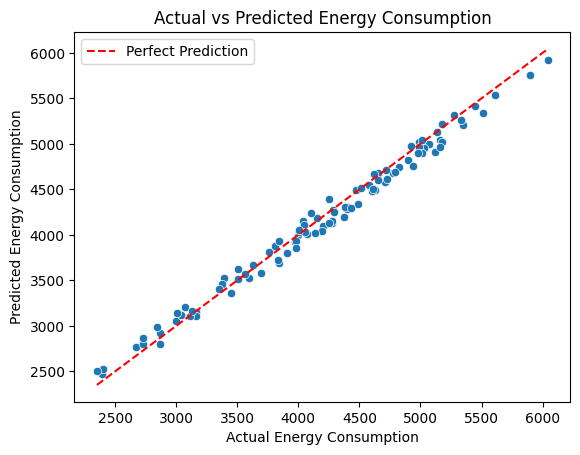

In [58]:
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label="Perfect Prediction")
plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.legend()
plt.show()
